# Challenge 03. Image Segmentation

### Description:
Image segmentation can be defined as dividing the image into segments by grouping pixels based on similarities in their color, intensity, or texture. Color-based segmentation assumes that homogeneous colors correspond to same region. Segments distribution heavily depends on the number of clusters defined. Nowadays, image segmentation is considered critical for several technologies. For example, AI heavily depends on image segmentaion when it needs to process or analyze an image. Image segmentation enables AI systems to understand digital images as information, such as detecting objects in the image. 

### Challenge:
The challenge is to apply image segmentation techniques to segment a plant into distinct regions.

### Part I - Libraries: 
1. **cv2** library is used to provide common features for computer vision and images applications.
2. **numpy** library is used to create different array objects and perform array manipulations.
3. **matplotlib.pyplot** library is used to show plots visualizations.

### Part II - User-defined functions:  
- `plot_image(image, title)` function plots the result of images. It shows the image, sets the title of the image, and hides the axis.

### Part III - Image Conversion:
The image color is converted from BGR to RGB to display the correct colors of the image.

### Part IV - Image preparation:    
The image is flattend from 3D to 2D array consisting of all pixels as rows and RGB color. Then, the type of the array is converted to  float, so it can be used in `cv2.kmeans()` built-in function.

### Part V - Code Explanation: 
The technique used to segment the picture into distinct regions is K-means clustering. Cv2 has a built-in function to apply the K-means on the image. `cv2.kmeans()` takes serveral parameters: input image as a 2D array of number of pixels and RGB colors, number of clusters, initial lables to clusters, criteria, maximum number of iterations, and a flag to specify how the initial cluster centers are selected.
        
The criteria by which the K-means algorithm will cluster the pixels is declared by specifying the rules and values for them. In this program the rules are maximum number of iterations and epsilon. `cv2.kmeans()` returns 3 values: compactness as the sum of squared distances between centers and points, clusters' labels, and an array of final centroids. 

The difficulty we faced in implementing the K-means is figuring out the best number of clusters to the image. The solution was found by trying some values for the number of clusters by starting with 3 clusters and then incrementing the number of clusters until the best clustered image is found. 

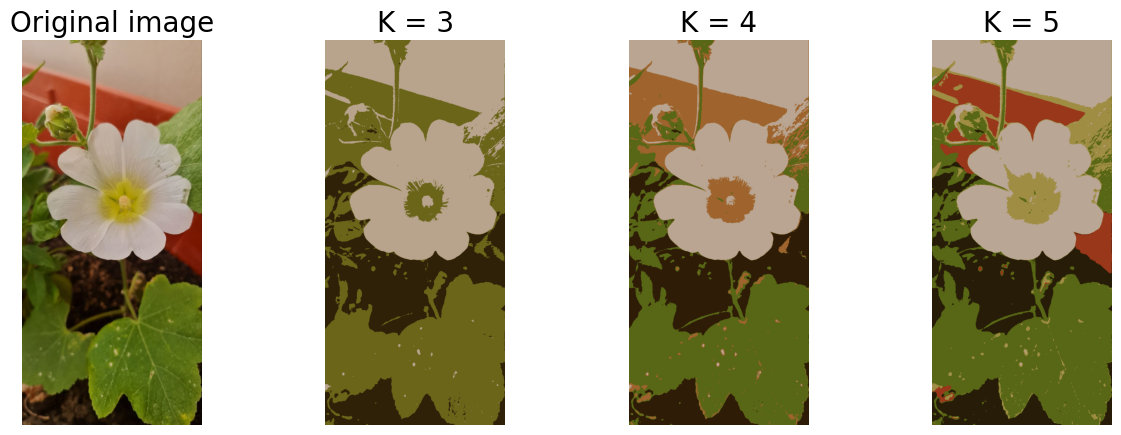

In [9]:
# imported libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# plots an image with the title
def plot_image(image, title):
    plt.imshow(image);
    plt.title(title, size=20);
    plt.axis('off')
    
# read the image and convert the color from BGR to RGB
original_image = cv2.imread('images/Challenge3.jpg') 
image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

vectorized = np.float32(image.reshape((-1,3))) # flatten the image to vector by converting from 3D to 2D then convert it to float

criteria = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 10, 1.0) 

# number of clusters
K1 = 3
K2 = 4
K3 = 5

# number of trials
attempts= 10 

# applying K-means technique to the image
compactness, label, center = cv2.kmeans(vectorized, K1, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center) # convert the array from float to unsigned integer 8-bits
result = center[label.flatten()] # flatten() converts the lables array to 1D array
image_3_clusters = result.reshape((image.shape)) # reshape the image to its original shape

compactness, label, center = cv2.kmeans(vectorized, K2, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center)
result = center[label.flatten()]
image_4_clusters = result.reshape((image.shape))

compactness, label, center = cv2.kmeans(vectorized, K3, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center)
result = center[label.flatten()]
image_5_clusters = result.reshape((image.shape))

# display all images in one row
plt.figure(figsize=(15,5))
plt.subplot(141), plot_image(image, 'Original image')
plt.subplot(142), plot_image(image_3_clusters,'K = {}'.format(K1))
plt.subplot(143), plot_image(image_4_clusters,'K = {}'.format(K2))
plt.subplot(144), plot_image(image_5_clusters,'K = {}'.format(K3))

plt.show()

### Part VI -Observations:
>while k = number of clusters
1. k = 3: The flower can be easily detected but the surroundings are not clear.  
2. k = 4: The flower and leaves can be easily detected but what is behind the flower is not clear and can not be distinguished.  
3. k = 5: The main parts of the image, such as flower, leaves, sand, and container, are very clear and can be easily detected.  

Finally, the best number of clusters was **five** because it distinguishes between the main parts of the image.